# 01 — Analyse Exploratoire des Données (EDA)
## Projet ObRail Europe — Prévision de fréquentation & Détection des pays en déclin

**Objectif** : Explorer les deux datasets ML produits par `build_dataset.py` afin de :
- Vérifier la qualité des données (valeurs manquantes, doublons, outliers)
- Comprendre la distribution des variables et de la cible
- Identifier les patterns temporels utiles à la modélisation
- Préparer les visualisations requises pour le rapport final

---
## 0. Imports et configuration

In [1]:
import os
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

# Dossier de sauvegarde des figures
DOCS_DIR = Path("../../../../docs/ia/img/eda")
DOCS_DIR.mkdir(parents=True, exist_ok=True)

# Chemins des datasets ML
DATA_ML_DIR = Path("../../../../data/ml")
REGRESSION_DATASET_PATH    = DATA_ML_DIR / "regression_dataset_multihorizon.csv"
CLASSIF_DATASET_PATH       = DATA_ML_DIR / "classification_dataset_multihorizon.csv"

print("Régression dataset :", REGRESSION_DATASET_PATH.exists())
print("Classification dataset :", CLASSIF_DATASET_PATH.exists())

Régression dataset : True
Classification dataset : True


---
## 1. Chargement des datasets

In [2]:
df_reg = pd.read_csv(REGRESSION_DATASET_PATH).query("horizon == 1").copy()
df_clf = pd.read_csv(CLASSIF_DATASET_PATH).query("horizon == 1").copy()

# CompatibilitÃ© avec les noms de colonnes utilisÃ©s par ce notebook.
df_reg = df_reg.assign(
    year=df_reg["target_year"],
    co2_per_passenger=(df_reg["co2_emissions"] / df_reg["passengers"]).replace([np.inf, -np.inf], 0),
    co2_lag1=df_reg["co2_previous"],
    passengers_lag1=df_reg["passengers"],
    passengers_lag2=df_reg["passengers_previous"],
    passengers=df_reg["target_passengers"],
)
df_clf = df_clf.assign(
    year=df_clf["target_year"],
    co2_per_passenger=(df_clf["co2_emissions"] / df_clf["passengers"]).replace([np.inf, -np.inf], 0),
    co2_lag1=df_clf["co2_previous"],
    passengers_lag1=df_clf["passengers"],
    passengers_lag2=df_clf["passengers_previous"],
)

print(f"Dataset régression    : {df_reg.shape[0]} lignes × {df_reg.shape[1]} colonnes")
print(f"Dataset classification : {df_clf.shape[0]} lignes × {df_clf.shape[1]} colonnes")

Dataset régression    : 390 lignes × 31 colonnes
Dataset classification : 390 lignes × 31 colonnes


In [3]:
# Aperçu régression
df_reg.head(10)

,country_id,country_code,country_name,year,target_year,horizon,passengers_source,passengers_previous_source,target_passengers_source,co2_source,...,real_share_current,avg_distance_current,avg_duration_current,operator_count_current,network_data_available,target_passengers,co2_per_passenger,co2_lag1,passengers_lag1,passengers_lag2
0,1,AT,Austria,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,0.000000,0.000000,0.0,0,10606.0,0.006864,71.86017,10172.0,9713.0
1,2,BE,Belgium,2012,2012,1,eurostat,eurostat,eurostat_quarterly,eurostat,...,0.0,0.000000,0.000000,0.0,0,10300.0,0.010020,114.62304,10498.0,10498.0
2,3,BG,Bulgaria,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,322.176031,209.388961,1.0,1,1870.0,0.025837,47.89640,2059.0,2090.0
3,4,CH,Switzerland,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,0.000000,0.000000,0.0,0,18115.0,0.002244,45.16594,18320.0,17800.0
4,5,CY,Cyprus,2012,2012,1,structural_zero,structural_zero,structural_zero,eurostat,...,0.0,0.000000,0.000000,0.0,0,0.0,0.000000,8.08778,0.0,0.0
5,6,CZ,Czech Republic,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,335.024847,229.598739,1.0,1,7196.0,0.017387,118.25989,6669.0,6559.0
6,7,DE,Germany,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,0.000000,0.000000,0.0,0,93918.0,0.009022,829.78703,89316.0,82837.0
7,8,DK,Denmark,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,192.303349,125.877940,1.0,1,6534.0,0.006980,49.66861,6395.0,6148.0
8,9,EE,Estonia,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,160.044173,104.842042,1.0,1,235.0,0.077973,18.96417,243.0,247.0
9,10,ES,Spain,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,652.018095,418.251817,1.0,1,22170.0,0.012467,282.56271,22645.0,22044.0


In [4]:
# Aperçu classification
df_clf.head(10)

,country_id,country_code,country_name,year,target_year,horizon,passengers_source,passengers_previous_source,target_passengers_source,co2_source,...,real_share_current,avg_distance_current,avg_duration_current,operator_count_current,network_data_available,en_declin,co2_per_passenger,co2_lag1,passengers_lag1,passengers_lag2
0,1,AT,Austria,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,0.000000,0.000000,0.0,0,0,0.006864,71.86017,10172.0,9713.0
1,2,BE,Belgium,2012,2012,1,eurostat,eurostat,eurostat_quarterly,eurostat,...,0.0,0.000000,0.000000,0.0,0,1,0.010020,114.62304,10498.0,10498.0
2,3,BG,Bulgaria,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,322.176031,209.388961,1.0,1,1,0.025837,47.89640,2059.0,2090.0
3,4,CH,Switzerland,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,0.000000,0.000000,0.0,0,1,0.002244,45.16594,18320.0,17800.0
4,5,CY,Cyprus,2012,2012,1,structural_zero,structural_zero,structural_zero,eurostat,...,0.0,0.000000,0.000000,0.0,0,0,0.000000,8.08778,0.0,0.0
5,6,CZ,Czech Republic,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,335.024847,229.598739,1.0,1,0,0.017387,118.25989,6669.0,6559.0
6,7,DE,Germany,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,0.000000,0.000000,0.0,0,0,0.009022,829.78703,89316.0,82837.0
7,8,DK,Denmark,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,192.303349,125.877940,1.0,1,0,0.006980,49.66861,6395.0,6148.0
8,9,EE,Estonia,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,160.044173,104.842042,1.0,1,1,0.077973,18.96417,243.0,247.0
9,10,ES,Spain,2012,2012,1,eurostat,eurostat,eurostat,eurostat,...,0.0,652.018095,418.251817,1.0,1,1,0.012467,282.56271,22645.0,22044.0


---
## 2. Qualité des données

### 2.1 Valeurs manquantes

In [5]:
print("=== Valeurs manquantes — Régression ===")
missing_reg = df_reg.isna().sum()
print(missing_reg[missing_reg > 0] if missing_reg.sum() > 0 else "Aucune valeur manquante ✅")

print("\n=== Valeurs manquantes — Classification ===")
missing_clf = df_clf.isna().sum()
print(missing_clf[missing_clf > 0] if missing_clf.sum() > 0 else "Aucune valeur manquante ✅")

=== Valeurs manquantes — Régression ===
Aucune valeur manquante ✅

=== Valeurs manquantes — Classification ===
Aucune valeur manquante ✅


### 2.2 Doublons

In [6]:
dup_reg = df_reg.duplicated().sum()
dup_clf = df_clf.duplicated().sum()

print(f"Doublons dataset régression    : {dup_reg}")
print(f"Doublons dataset classification : {dup_clf}")

Doublons dataset régression    : 0
Doublons dataset classification : 0


### 2.3 Statistiques descriptives

In [7]:
print("=== Statistiques descriptives — Régression ===")
df_reg.describe().round(2)

=== Statistiques descriptives — Régression ===


,country_id,year,target_year,horizon,sample_weight,passengers,passengers_previous,passenger_growth_1y,co2_emissions,co2_previous,...,real_share_current,avg_distance_current,avg_duration_current,operator_count_current,network_data_available,target_passengers,co2_per_passenger,co2_lag1,passengers_lag1,passengers_lag2
count,390.00,390.00,390.00,390.0,390.00,390.00,390.00,390.00,390.00,390.00,...,390.00,390.00,390.00,390.00,390.00,390.00,390.00,390.00,390.00,390.00
mean,16.73,2018.00,2018.00,1.0,0.95,15000.06,14502.74,0.03,122.20,124.96,...,0.00,304.72,200.95,0.77,0.77,15000.06,0.02,124.96,14733.92,14502.74
std,9.84,3.75,3.75,0.0,0.12,24622.98,23864.66,0.20,179.07,182.53,...,0.05,261.30,172.33,0.44,0.42,24622.98,0.02,182.53,24217.33,23864.66
min,1.00,2012.00,2012.00,1.0,0.40,0.00,0.00,-0.65,1.38,1.38,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.38,0.00,0.00
25%,8.00,2015.00,2015.00,1.0,1.00,743.25,763.25,-0.01,18.64,18.82,...,0.00,122.47,80.79,1.00,1.00,743.25,0.01,18.82,743.25,763.25
50%,16.50,2018.00,2018.00,1.0,1.00,4651.50,4517.00,0.02,44.71,45.46,...,0.00,265.37,172.57,1.00,1.00,4651.50,0.01,45.46,4552.50,4517.00
75%,25.00,2021.00,2021.00,1.0,1.00,15356.25,15263.50,0.07,105.53,107.16,...,0.00,404.30,269.79,1.00,1.00,15356.25,0.02,107.16,15263.50,15263.50
max,34.00,2024.00,2024.00,1.0,1.00,109135.00,100252.00,1.01,834.50,834.50,...,1.00,1007.25,667.44,3.00,1.00,109135.00,0.11,834.50,101408.00,100252.00


In [8]:
print("=== Statistiques descriptives — Classification ===")
df_clf.describe().round(2)

=== Statistiques descriptives — Classification ===


,country_id,year,target_year,horizon,sample_weight,passengers,passengers_previous,passenger_growth_1y,co2_emissions,co2_previous,...,real_share_current,avg_distance_current,avg_duration_current,operator_count_current,network_data_available,en_declin,co2_per_passenger,co2_lag1,passengers_lag1,passengers_lag2
count,390.00,390.00,390.00,390.0,390.00,390.00,390.00,390.00,390.00,390.00,...,390.00,390.00,390.00,390.00,390.00,390.00,390.00,390.00,390.00,390.00
mean,16.73,2018.00,2018.00,1.0,0.95,14733.92,14502.74,0.03,122.20,124.96,...,0.00,304.72,200.95,0.77,0.77,0.28,0.02,124.96,14733.92,14502.74
std,9.84,3.75,3.75,0.0,0.12,24217.33,23864.66,0.20,179.07,182.53,...,0.05,261.30,172.33,0.44,0.42,0.45,0.02,182.53,24217.33,23864.66
min,1.00,2012.00,2012.00,1.0,0.40,0.00,0.00,-0.65,1.38,1.38,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.38,0.00,0.00
25%,8.00,2015.00,2015.00,1.0,1.00,743.25,763.25,-0.01,18.64,18.82,...,0.00,122.47,80.79,1.00,1.00,0.00,0.01,18.82,743.25,763.25
50%,16.50,2018.00,2018.00,1.0,1.00,4552.50,4517.00,0.02,44.71,45.46,...,0.00,265.37,172.57,1.00,1.00,0.00,0.01,45.46,4552.50,4517.00
75%,25.00,2021.00,2021.00,1.0,1.00,15263.50,15263.50,0.07,105.53,107.16,...,0.00,404.30,269.79,1.00,1.00,1.00,0.02,107.16,15263.50,15263.50
max,34.00,2024.00,2024.00,1.0,1.00,101408.00,100252.00,1.01,834.50,834.50,...,1.00,1007.25,667.44,3.00,1.00,1.00,0.11,834.50,101408.00,100252.00


### 2.4 Couverture pays et années

In [9]:
print(f"Pays couverts  : {df_reg['country_name'].nunique()}")
print(f"Années couvertes: {df_reg['year'].min()} → {df_reg['year'].max()}")
print(f"\nListe des pays :")
print(sorted(df_reg['country_name'].unique()))

Pays couverts  : 30
Années couvertes: 2012 → 2024

Liste des pays :
['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czech Republic', 'Denmark', 'Estonia', 'Finland', 'France', 'Germany', 'Greece', 'Hungary', 'Ireland', 'Italy', 'Latvia', 'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Norway', 'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain', 'Sweden', 'Switzerland', 'United Kingdom']


---
## 3. Distribution de la cible régression : `passengers`

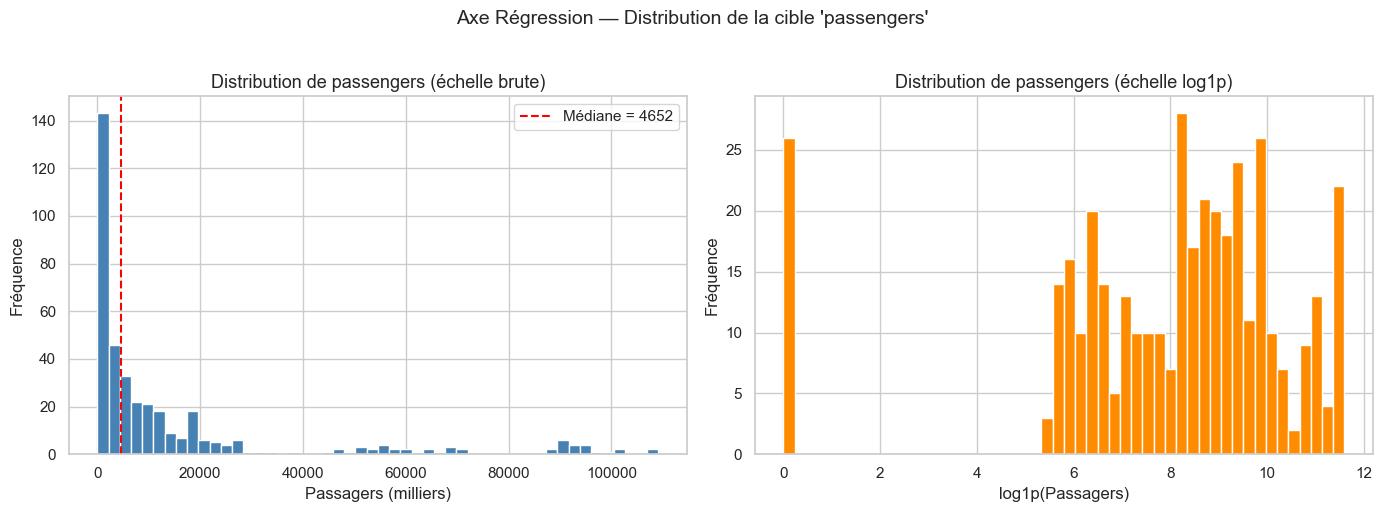

Figure sauvegardée : docs/fig_distribution_passengers.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution brute
axes[0].hist(df_reg["passengers"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution de passengers (échelle brute)", fontsize=13)
axes[0].set_xlabel("Passagers (milliers)")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(df_reg["passengers"].median(), color="red", linestyle="--",
                label=f"Médiane = {df_reg['passengers'].median():.0f}")
axes[0].legend()

# Distribution log1p (pour mieux visualiser l'asymétrie)
axes[1].hist(np.log1p(df_reg["passengers"]), bins=50, color="darkorange", edgecolor="white")
axes[1].set_title("Distribution de passengers (échelle log1p)", fontsize=13)
axes[1].set_xlabel("log1p(Passagers)")
axes[1].set_ylabel("Fréquence")

plt.suptitle("Axe Régression — Distribution de la cible 'passengers'", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_distribution_passengers.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_distribution_passengers.png")

In [11]:
# Statistiques clés de la cible régression
stats_passengers = df_reg["passengers"].describe()
print("Statistiques de 'passengers' :")
print(stats_passengers.round(0))
print(f"\nPart des observations > 100 000 : {(df_reg['passengers'] > 100_000).mean()*100:.1f}%")
print(f"Part des observations < 1 000   : {(df_reg['passengers'] < 1_000).mean()*100:.1f}%")

Statistiques de 'passengers' :
count       390.0
mean      15000.0
std       24623.0
min           0.0
25%         743.0
50%        4652.0
75%       15356.0
max      109135.0
Name: passengers, dtype: float64

Part des observations > 100 000 : 1.3%
Part des observations < 1 000   : 27.7%


---
## 4. Distribution de la cible classification : `en_declin`

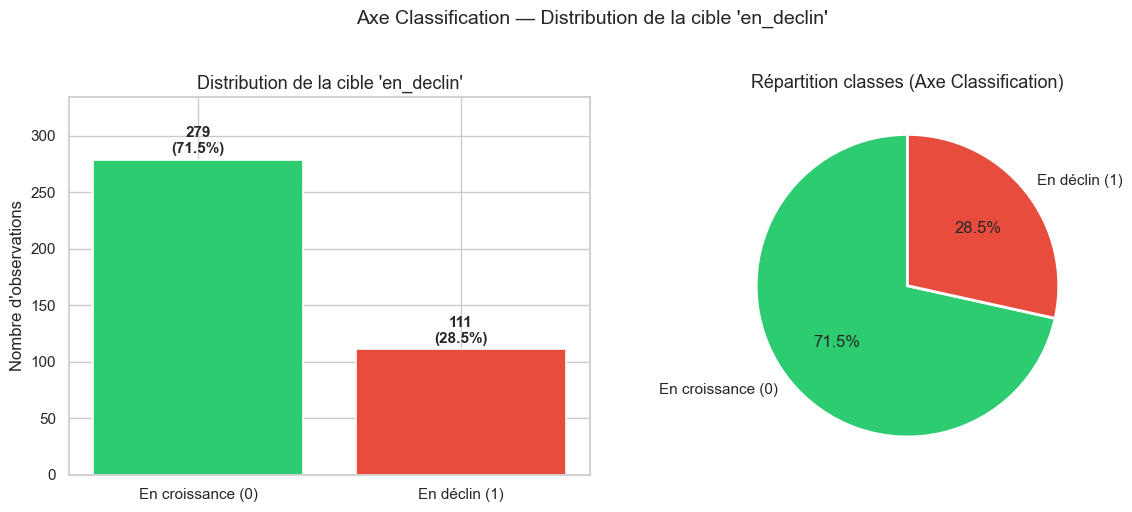

Figure sauvegardée : docs/fig_distribution_en_declin.png


In [12]:
counts = df_clf["en_declin"].value_counts()
labels = ["En croissance (0)", "En déclin (1)"]
colors = ["#2ecc71", "#e74c3c"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Barplot
bars = axes[0].bar(["En croissance (0)", "En déclin (1)"],
                   counts.values, color=colors, edgecolor="white", linewidth=1.2)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f"{val}\n({val/len(df_clf)*100:.1f}%)",
                 ha="center", va="bottom", fontsize=11, fontweight="bold")
axes[0].set_title("Distribution de la cible 'en_declin'", fontsize=13)
axes[0].set_ylabel("Nombre d'observations")
axes[0].set_ylim(0, counts.max() * 1.2)

# Camembert
axes[1].pie(counts.values, labels=labels, colors=colors,
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Répartition classes (Axe Classification)", fontsize=13)

plt.suptitle("Axe Classification — Distribution de la cible 'en_declin'", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_distribution_en_declin.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_distribution_en_declin.png")

---
## 5. Évolution temporelle — Top 8 pays par fréquentation

In [13]:
# Identifier les 8 pays avec la fréquentation moyenne la plus élevée
top8_countries = (
    df_reg.groupby("country_name")["passengers"]
    .mean()
    .nlargest(8)
    .index.tolist()
)
print("Top 8 pays (fréquentation moyenne) :", top8_countries)

Top 8 pays (fréquentation moyenne) : ['Germany', 'France', 'United Kingdom', 'Italy', 'Spain', 'Poland', 'Switzerland', 'Netherlands']


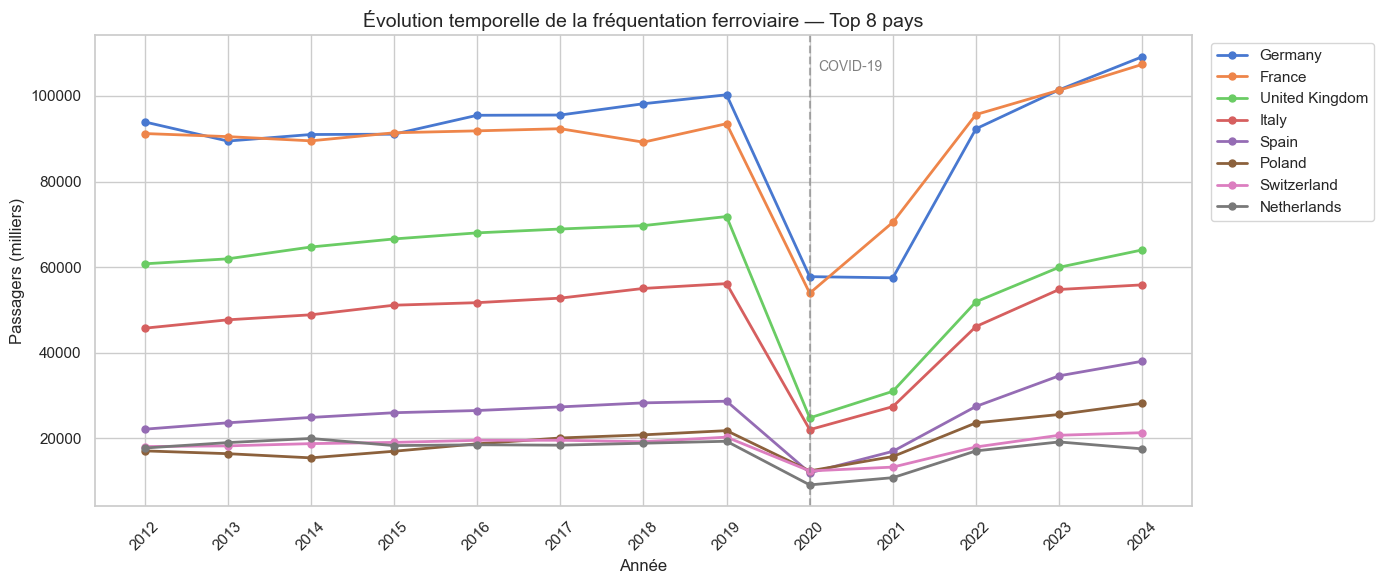

Figure sauvegardée : docs/fig_evolution_temporelle.png


In [14]:
df_top8 = df_reg[df_reg["country_name"].isin(top8_countries)]

fig, ax = plt.subplots(figsize=(14, 6))

for country in top8_countries:
    data = df_top8[df_top8["country_name"] == country].sort_values("year")
    ax.plot(data["year"], data["passengers"], marker="o", linewidth=2,
            markersize=5, label=country)

# Annotation COVID
ax.axvline(2020, color="gray", linestyle="--", alpha=0.6, linewidth=1.5)
ax.text(2020.1, ax.get_ylim()[1] * 0.95, "COVID-19", color="gray",
        fontsize=10, va="top")

ax.set_title("Évolution temporelle de la fréquentation ferroviaire — Top 8 pays",
             fontsize=14)
ax.set_xlabel("Année")
ax.set_ylabel("Passagers (milliers)")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", frameon=True)
ax.set_xticks(range(df_reg["year"].min(), df_reg["year"].max() + 1))
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_evolution_temporelle.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_evolution_temporelle.png")

---
## 6. Matrice de corrélation des features numériques

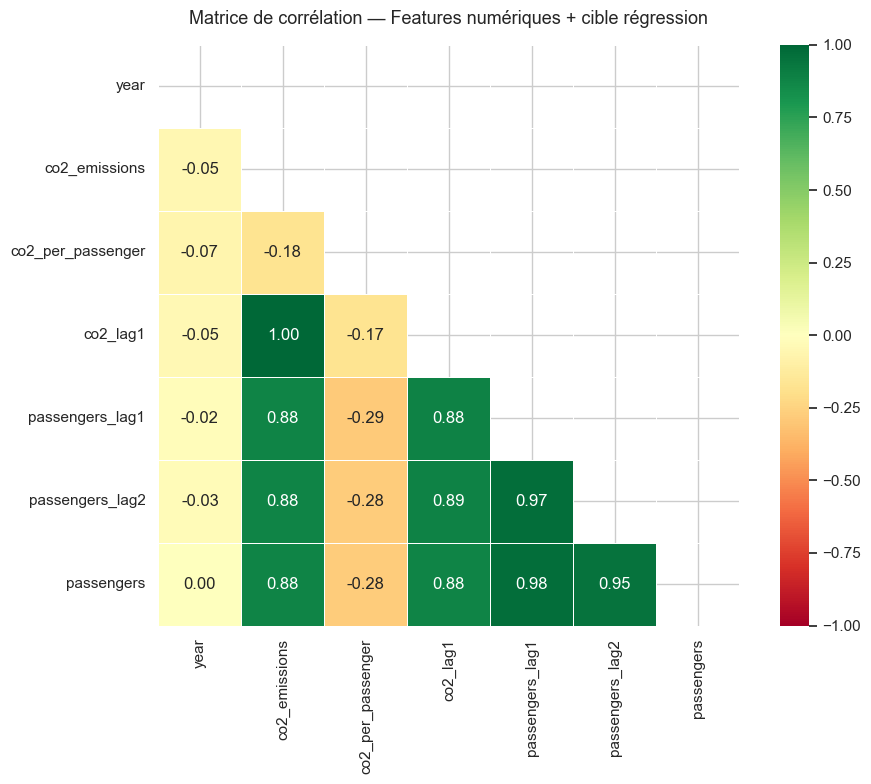

Figure sauvegardée : docs/fig_correlation_matrix.png


In [15]:
# Features numériques communes aux deux axes
numeric_features = [
    "year",
    "co2_emissions",
    "co2_per_passenger",
    "co2_lag1",
    "passengers_lag1",
    "passengers_lag2",
    "passengers",   # cible régression, pour voir la corrélation avec les features
]

corr = df_reg[numeric_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Masque triangle supérieur
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    mask=mask,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matrice de corrélation — Features numériques + cible régression",
             fontsize=13, pad=15)

plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_correlation_matrix.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_correlation_matrix.png")

In [16]:
# Corrélations avec la cible régression
print("Corrélation des features avec 'passengers' (cible régression) :")
corr_target = corr["passengers"].drop("passengers").sort_values(ascending=False)
print(corr_target.round(3))

Corrélation des features avec 'passengers' (cible régression) :
passengers_lag1      0.976
passengers_lag2      0.950
co2_emissions        0.876
co2_lag1             0.875
year                 0.001
co2_per_passenger   -0.281
Name: passengers, dtype: float64


---
## 7. Analyse des variables lag

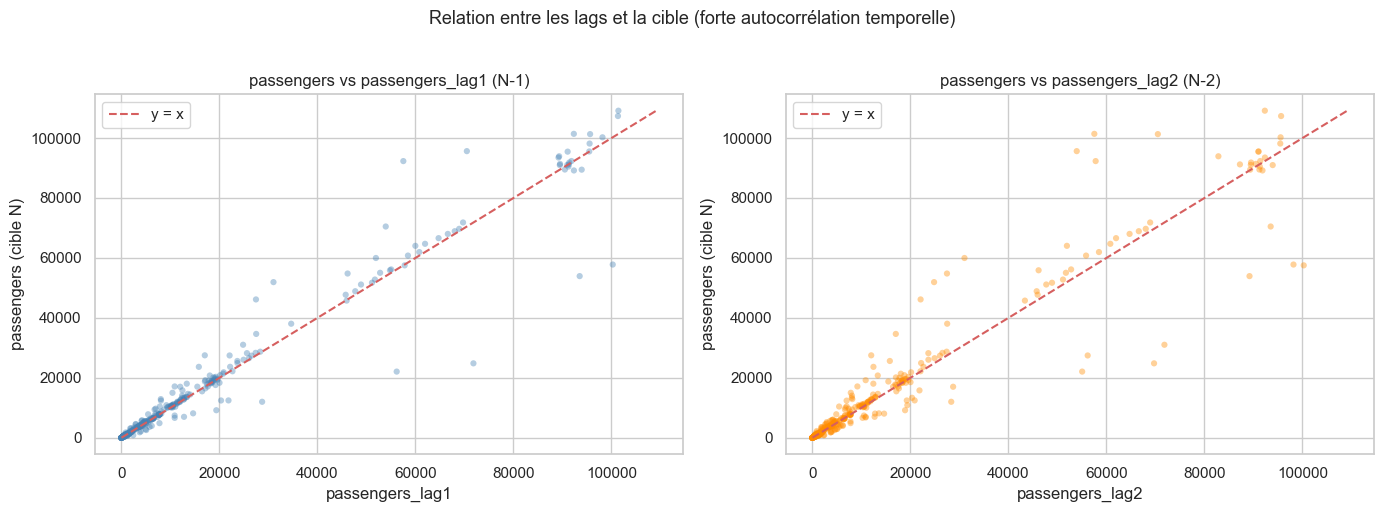

Figure sauvegardée : docs/fig_lag_scatter.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# passengers vs passengers_lag1
axes[0].scatter(df_reg["passengers_lag1"], df_reg["passengers"],
                alpha=0.4, color="steelblue", edgecolors="none", s=20)
# Droite y = x
max_val = df_reg[["passengers", "passengers_lag1"]].max().max()
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="y = x")
axes[0].set_title("passengers vs passengers_lag1 (N-1)", fontsize=12)
axes[0].set_xlabel("passengers_lag1")
axes[0].set_ylabel("passengers (cible N)")
axes[0].legend()

# passengers vs passengers_lag2
axes[1].scatter(df_reg["passengers_lag2"], df_reg["passengers"],
                alpha=0.4, color="darkorange", edgecolors="none", s=20)
axes[1].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="y = x")
axes[1].set_title("passengers vs passengers_lag2 (N-2)", fontsize=12)
axes[1].set_xlabel("passengers_lag2")
axes[1].set_ylabel("passengers (cible N)")
axes[1].legend()

plt.suptitle("Relation entre les lags et la cible (forte autocorrélation temporelle)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_lag_scatter.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_lag_scatter.png")

---
## 8. Distribution de `en_declin` par année

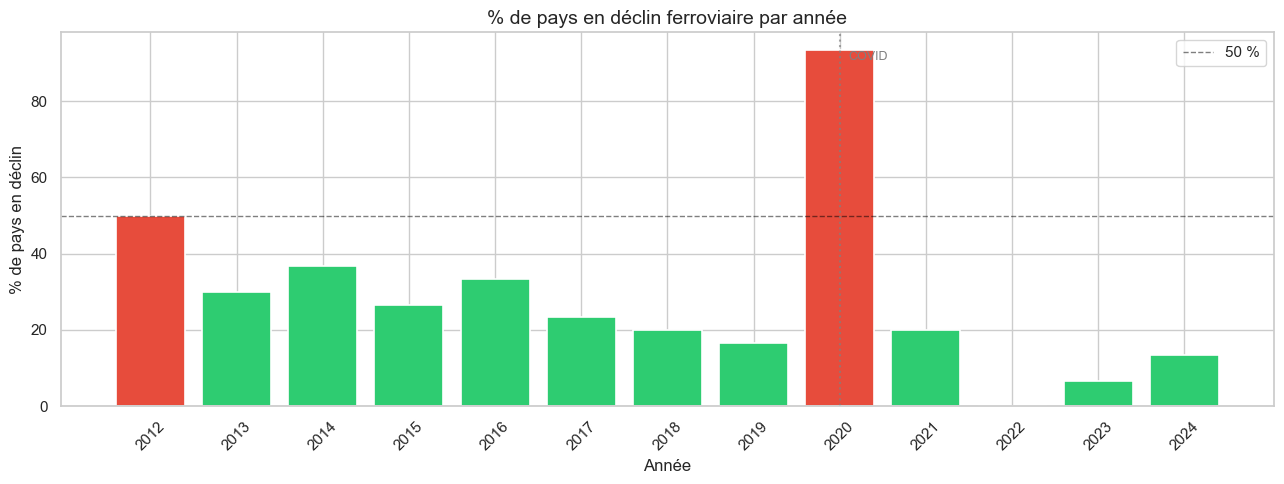

Figure sauvegardée : docs/fig_declin_par_annee.png

Détail par année :
      en_declin  total  pct_declin
year                              
2012         15     30        50.0
2013          9     30        30.0
2014         11     30        36.7
2015          8     30        26.7
2016         10     30        33.3
2017          7     30        23.3
2018          6     30        20.0
2019          5     30        16.7
2020         28     30        93.3
2021          6     30        20.0
2022          0     30         0.0
2023          2     30         6.7
2024          4     30        13.3


In [18]:
# Nombre de pays en déclin par année
declin_by_year = (
    df_clf.groupby("year")["en_declin"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "en_declin", "count": "total"})
)
declin_by_year["pct_declin"] = declin_by_year["en_declin"] / declin_by_year["total"] * 100

fig, ax = plt.subplots(figsize=(13, 5))
colors_bar = ["#e74c3c" if p >= 50 else "#2ecc71" for p in declin_by_year["pct_declin"]]
bars = ax.bar(declin_by_year.index, declin_by_year["pct_declin"],
              color=colors_bar, edgecolor="white", linewidth=1.2)

ax.axhline(50, color="black", linestyle="--", linewidth=1, alpha=0.5, label="50 %")
ax.set_title("% de pays en déclin ferroviaire par année", fontsize=14)
ax.set_xlabel("Année")
ax.set_ylabel("% de pays en déclin")
ax.set_xticks(declin_by_year.index)
ax.tick_params(axis="x", rotation=45)
ax.legend()

# Annotations COVID
ax.axvline(2020, color="gray", linestyle=":", alpha=0.7)
ax.text(2020.1, ax.get_ylim()[1] * 0.95, "COVID", color="gray", fontsize=9, va="top")

plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_declin_par_annee.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_declin_par_annee.png")
print("\nDétail par année :")
print(declin_by_year.round(1))

---
## 9. Distribution des émissions CO₂

C:\Users\manso\AppData\Local\Temp\ipykernel_35420\297839013.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\manso\AppData\Local\Temp\ipykernel_35420\297839013.py:23: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(DOCS_DIR / "fig_distribution_co2.png", bbox_inches="tight")
C:\Users\manso\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


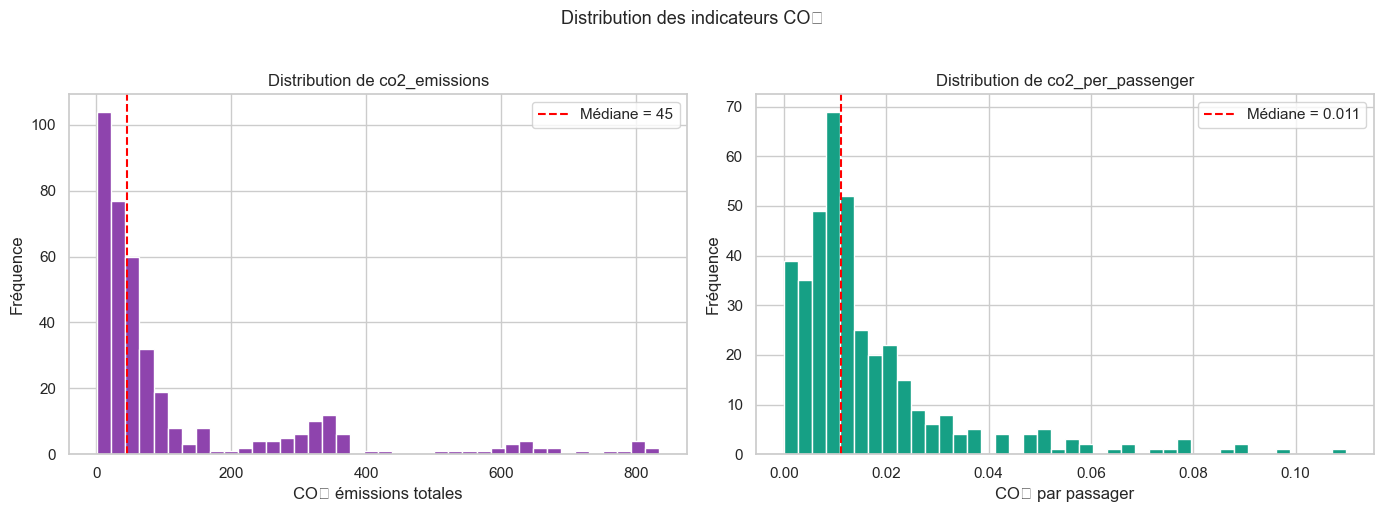

Figure sauvegardée : docs/fig_distribution_co2.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# co2_emissions
axes[0].hist(df_reg["co2_emissions"], bins=40, color="#8e44ad", edgecolor="white")
axes[0].set_title("Distribution de co2_emissions", fontsize=12)
axes[0].set_xlabel("CO₂ émissions totales")
axes[0].set_ylabel("Fréquence")
axes[0].axvline(df_reg["co2_emissions"].median(), color="red", linestyle="--",
                label=f"Médiane = {df_reg['co2_emissions'].median():.0f}")
axes[0].legend()

# co2_per_passenger
axes[1].hist(df_reg["co2_per_passenger"], bins=40, color="#16a085", edgecolor="white")
axes[1].set_title("Distribution de co2_per_passenger", fontsize=12)
axes[1].set_xlabel("CO₂ par passager")
axes[1].set_ylabel("Fréquence")
axes[1].axvline(df_reg["co2_per_passenger"].median(), color="red", linestyle="--",
                label=f"Médiane = {df_reg['co2_per_passenger'].median():.3f}")
axes[1].legend()

plt.suptitle("Distribution des indicateurs CO₂", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_distribution_co2.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_distribution_co2.png")

---
## 10. Boxplot des features numériques (détection d'outliers)

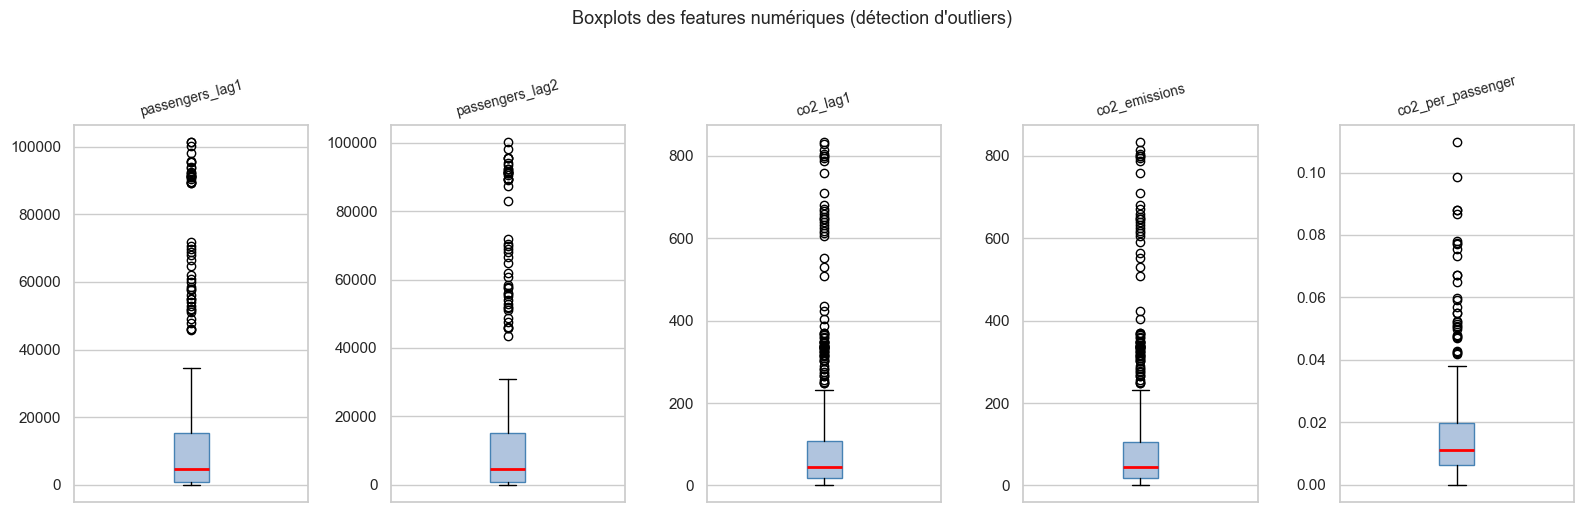

Figure sauvegardée : docs/fig_boxplots_features.png


In [20]:
lag_features = ["passengers_lag1", "passengers_lag2", "co2_lag1",
                "co2_emissions", "co2_per_passenger"]

fig, axes = plt.subplots(1, len(lag_features), figsize=(16, 5))

for ax, col in zip(axes, lag_features):
    ax.boxplot(df_reg[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue", color="steelblue"),
               medianprops=dict(color="red", linewidth=2))
    ax.set_title(col, fontsize=10, rotation=15)
    ax.set_xticks([])

plt.suptitle("Boxplots des features numériques (détection d'outliers)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(DOCS_DIR / "fig_boxplots_features.png", bbox_inches="tight")
plt.show()
print("Figure sauvegardée : docs/fig_boxplots_features.png")

---
## 11. Résumé des observations EDA

In [21]:
print("=" * 60)
print("SYNTHÈSE EDA — PROJET OBRAIL EUROPE")
print("=" * 60)

print("\n📊 Datasets")
print(f"  Lignes (après suppression NaN lag) : {len(df_reg)}")
print(f"  Pays couverts                       : {df_reg['country_name'].nunique()}")
print(f"  Période                             : {df_reg['year'].min()}–{df_reg['year'].max()}")

print("\n🎯 Cible Régression (passengers)")
print(f"  Min      : {df_reg['passengers'].min():.0f}")
print(f"  Max      : {df_reg['passengers'].max():.0f}")
print(f"  Médiane  : {df_reg['passengers'].median():.0f}")
print(f"  → Distribution fortement asymétrique (skewed right)")

print("\n🎯 Cible Classification (en_declin)")
vc = df_clf["en_declin"].value_counts()
print(f"  Classe 0 (En croissance) : {vc[0]} ({vc[0]/len(df_clf)*100:.1f}%)")
print(f"  Classe 1 (En déclin)     : {vc[1]} ({vc[1]/len(df_clf)*100:.1f}%)")
print(f"  → Déséquilibre modéré → utiliser F1-Score comme métrique principale")

print("\n✅ Qualité des données")
print(f"  Valeurs manquantes : {df_reg.isna().sum().sum()} (régression) | {df_clf.isna().sum().sum()} (clf)")
print(f"  Doublons           : {df_reg.duplicated().sum()} (régression) | {df_clf.duplicated().sum()} (clf)")

print("\n📈 Corrélations clés avec passengers")
corr_passengers = df_reg[["year","co2_emissions","co2_per_passenger",
                           "co2_lag1","passengers_lag1","passengers_lag2",
                           "passengers"]].corr()["passengers"].drop("passengers")
for feat, val in corr_passengers.sort_values(ascending=False).items():
    print(f"  {feat:25s} : {val:.3f}")

print("\n" + "=" * 60)

SYNTHÈSE EDA — PROJET OBRAIL EUROPE

📊 Datasets
  Lignes (après suppression NaN lag) : 390
  Pays couverts                       : 30
  Période                             : 2012–2024

🎯 Cible Régression (passengers)
  Min      : 0
  Max      : 109135
  Médiane  : 4652
  → Distribution fortement asymétrique (skewed right)

🎯 Cible Classification (en_declin)
  Classe 0 (En croissance) : 279 (71.5%)
  Classe 1 (En déclin)     : 111 (28.5%)
  → Déséquilibre modéré → utiliser F1-Score comme métrique principale

✅ Qualité des données
  Valeurs manquantes : 0 (régression) | 0 (clf)
  Doublons           : 0 (régression) | 0 (clf)

📈 Corrélations clés avec passengers
  passengers_lag1           : 0.976
  passengers_lag2           : 0.950
  co2_emissions             : 0.876
  co2_lag1                  : 0.875
  year                      : 0.001
  co2_per_passenger         : -0.281



---
## 12. Figures produites

| Figure | Fichier |
|--------|---------|
| Distribution de `passengers` (brute + log1p) | `docs/fig_distribution_passengers.png` |
| Distribution de `en_declin` (barplot + camembert) | `docs/fig_distribution_en_declin.png` |
| Évolution temporelle top 8 pays | `docs/fig_evolution_temporelle.png` |
| Matrice de corrélation | `docs/fig_correlation_matrix.png` |
| Scatter lags vs cible | `docs/fig_lag_scatter.png` |
| % pays en déclin par année | `docs/fig_declin_par_annee.png` |
| Distribution CO₂ | `docs/fig_distribution_co2.png` |
| Boxplots features (outliers) | `docs/fig_boxplots_features.png` |